In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb
import json
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/processed/features.csv')
with open('../data/processed/models/feature_cols.json') as f:
    feature_cols = json.load(f)

X = df[feature_cols]
y = df['Churn_binary']

# Load model
model = lgb.Booster(model_file='../data/processed/models/lgbm_churn.txt')

print(f"Data: {X.shape}")
print(f"Features: {feature_cols}")

Data: (7043, 27)
Features: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Contract_encoded', 'InternetService_encoded', 'PaymentMethod_encoded', 'recency_risk', 'service_count', 'monetary_value', 'monthly_to_total_ratio', 'charge_per_month', 'clv_proxy', 'is_high_value', 'contract_stability', 'digital_engagement']


In [2]:
explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X)

# Binary classification trả về list [class_0, class_1] — lấy class 1 (churn)
shap_values = shap_values_raw[1] if isinstance(shap_values_raw, list) else shap_values_raw

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP computed ✅")

SHAP values shape: (7043, 27)
SHAP computed ✅


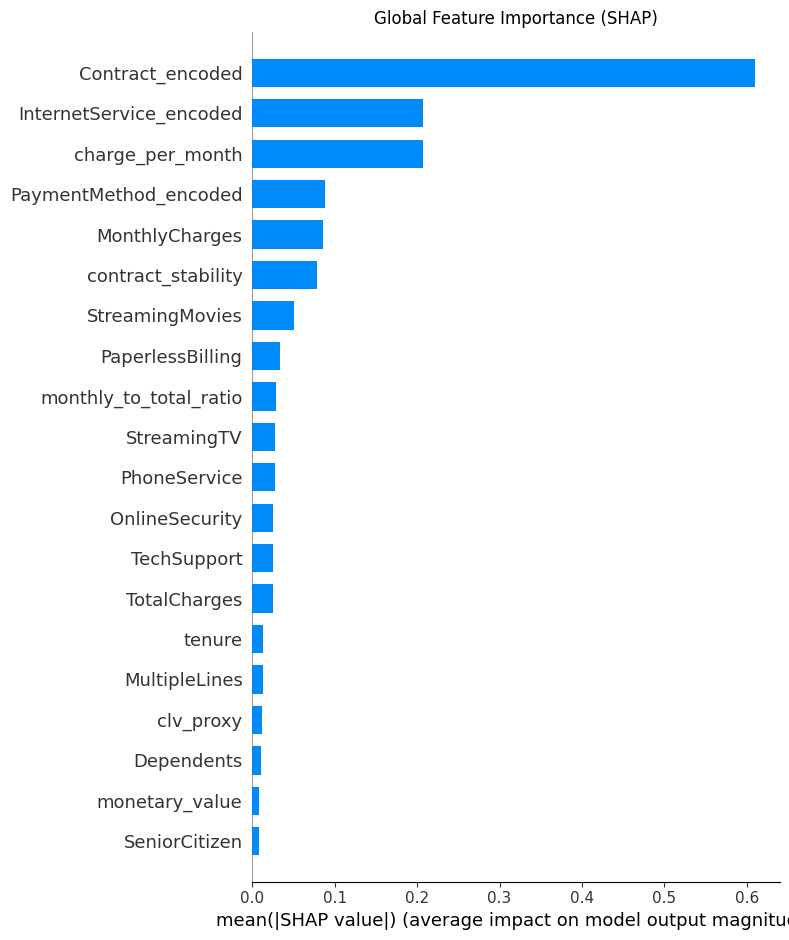

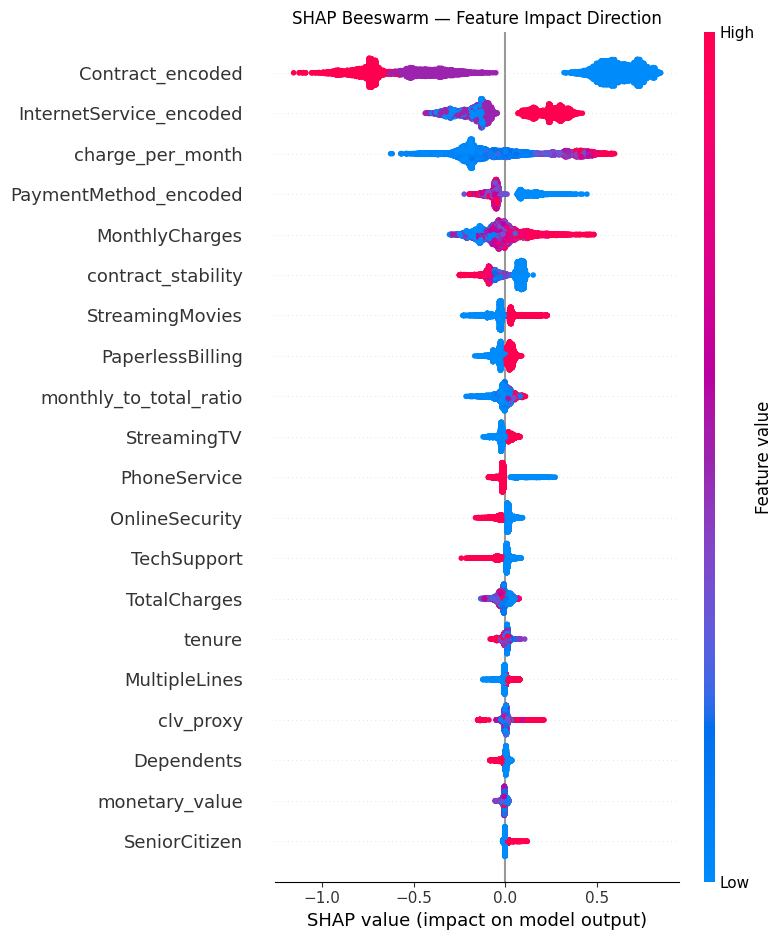

In [3]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, plot_type='bar', show=False)
plt.title('Global Feature Importance (SHAP)')
plt.tight_layout()
plt.savefig('../data/processed/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm plot — thấy direction của từng feature
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction')
plt.tight_layout()
plt.savefig('../data/processed/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

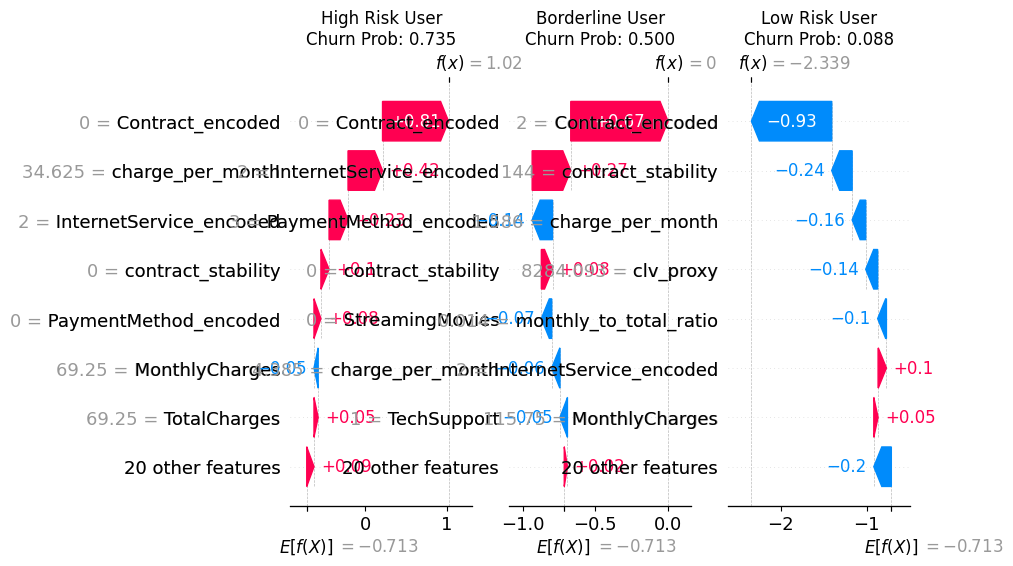

In [4]:
y_pred_proba = model.predict(X)
high_risk_idx = y_pred_proba.argmax()
low_risk_idx = y_pred_proba.argmin()
mid_risk_idx = np.abs(y_pred_proba - 0.5).argmin()

# Lấy expected_value cho class 1
base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, idx, title in zip(
    axes,
    [high_risk_idx, mid_risk_idx, low_risk_idx],
    ['High Risk User', 'Borderline User', 'Low Risk User']
):
    shap_exp = shap.Explanation(
        values=shap_values[idx],
        base_values=base_value,
        data=X.iloc[idx].values,
        feature_names=feature_cols
    )
    plt.sca(ax)
    shap.plots.waterfall(shap_exp, show=False, max_display=8)
    ax.set_title(f'{title}\nChurn Prob: {y_pred_proba[idx]:.3f}')

plt.tight_layout()
plt.savefig('../data/processed/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

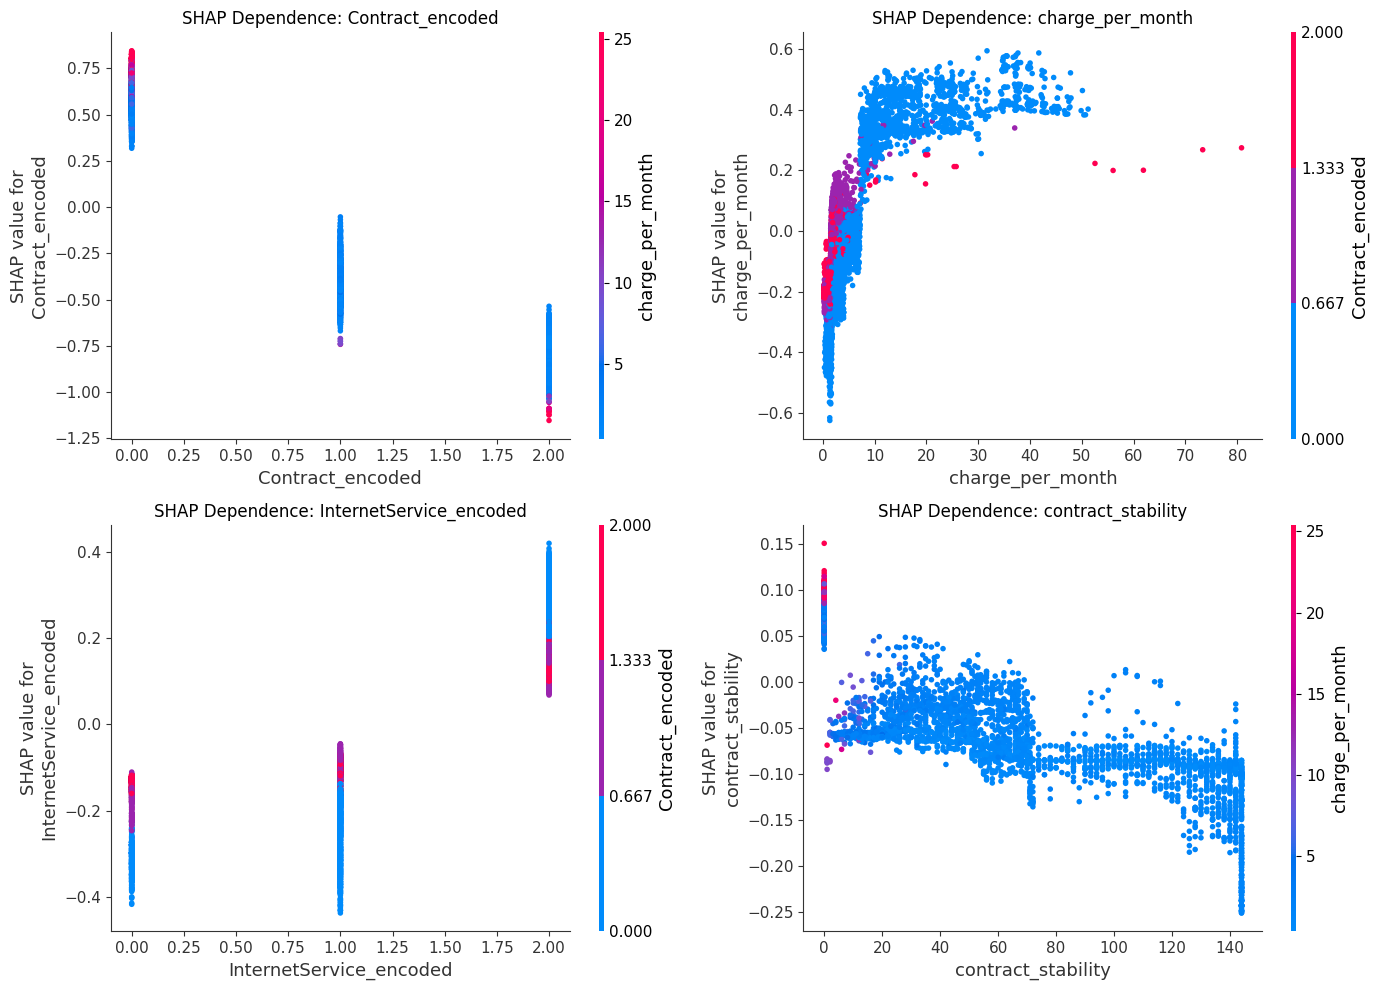

In [5]:
top_features = ['Contract_encoded', 'charge_per_month',
                'InternetService_encoded', 'contract_stability']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat in zip(axes.flatten(), top_features):
    shap.dependence_plot(
        feat, shap_values, X,
        ax=ax, show=False,
        interaction_index='auto'
    )
    ax.set_title(f'SHAP Dependence: {feat}')

plt.tight_layout()
plt.savefig('../data/processed/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Tính mean absolute SHAP per feature
shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("=== BUSINESS INTERPRETATION ===\n")
print("Top features TĂNG nguy cơ churn:")
for _, row in shap_importance.head(5).iterrows():
    print(f"  {row['feature']:<30} impact: {row['mean_abs_shap']:.4f}")

print("\n=== GỢI Ý ACTION ===")
print("1. Contract_encoded thấp (month-to-month) → Offer upgrade to annual contract")
print("2. charge_per_month cao → Review pricing, offer loyalty discount")
print("3. InternetService Fiber → Check service quality complaints")
print("4. tenure thấp → Strengthen onboarding experience")

shap_importance.to_csv('../data/processed/shap_importance.csv', index=False)
print("\nSHAP importance saved ✅")

=== BUSINESS INTERPRETATION ===

Top features TĂNG nguy cơ churn:
  Contract_encoded               impact: 0.6099
  InternetService_encoded        impact: 0.2075
  charge_per_month               impact: 0.2072
  PaymentMethod_encoded          impact: 0.0888
  MonthlyCharges                 impact: 0.0862

=== GỢI Ý ACTION ===
1. Contract_encoded thấp (month-to-month) → Offer upgrade to annual contract
2. charge_per_month cao → Review pricing, offer loyalty discount
3. InternetService Fiber → Check service quality complaints
4. tenure thấp → Strengthen onboarding experience

SHAP importance saved ✅
